# Standard vs probabilistic Hough on synthetic quadrilaterals

This notebook compares two `skimage` line detectors on the same synthetic quadrilateral examples:

- `hough_line` + `hough_line_peaks`: the **standard Hough transform**
- `probabilistic_hough_line`: the **progressive probabilistic Hough transform**

We want to test two situations:

1. a quadrilateral with one side that is **weaker** and **shorter** than the others
2. a quadrilateral with **strong internal clutter**

The useful comparison is this:

- standard Hough returns peaks in **global line parameter space**
- probabilistic Hough returns **actual line segments**

To make the outputs easier to compare, I will print both in a similar geometric format using:

- angle `theta`
- offset `rho`
- a strength-like quantity

For standard Hough, the strength is the **vote count**.
For probabilistic Hough, the strength is the **segment length**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.draw import line_aa
from skimage.feature import canny
from skimage.filters import gaussian
from skimage.transform import hough_line, hough_line_peaks, probabilistic_hough_line

plt.rcParams['figure.dpi'] = 120

H, W = 180, 180


def draw_segment(img, p0, p1, value=1.0):
    rr, cc, val = line_aa(int(round(p0[0])), int(round(p0[1])), int(round(p1[0])), int(round(p1[1])))
    valid = (rr >= 0) & (rr < img.shape[0]) & (cc >= 0) & (cc < img.shape[1])
    img[rr[valid], cc[valid]] = np.maximum(img[rr[valid], cc[valid]], value * val[valid])


def partial_segment(p0, p1, t0, t1):
    p0 = np.asarray(p0, dtype=float)
    p1 = np.asarray(p1, dtype=float)
    a = p0 + t0 * (p1 - p0)
    b = p0 + t1 * (p1 - p0)
    return a, b


def line_box_intersections(theta, rho, shape, eps=1e-9):
    h, w = shape
    a = np.cos(theta)
    b = np.sin(theta)
    points = []

    if abs(b) > eps:
        y0 = (rho - a * 0) / b
        y1 = (rho - a * (w - 1)) / b
        if 0 <= y0 <= h - 1:
            points.append((0.0, y0))
        if 0 <= y1 <= h - 1:
            points.append((w - 1.0, y1))

    if abs(a) > eps:
        x0 = (rho - b * 0) / a
        x1 = (rho - b * (h - 1)) / a
        if 0 <= x0 <= w - 1:
            points.append((x0, 0.0))
        if 0 <= x1 <= w - 1:
            points.append((x1, h - 1.0))

    unique = []
    for x, y in points:
        if not any(abs(x - ux) < 1e-6 and abs(y - uy) < 1e-6 for ux, uy in unique):
            unique.append((x, y))

    return unique[:2] if len(unique) >= 2 else None


def detect_standard_lines(img, canny_sigma=1.2, low_threshold=0.03, high_threshold=0.10, num_peaks=8):
    edges = canny(img, sigma=canny_sigma, low_threshold=low_threshold, high_threshold=high_threshold)
    accumulator, thetas, rhos = hough_line(edges)
    peaks = hough_line_peaks(accumulator, thetas, rhos, num_peaks=num_peaks)
    return edges, accumulator, thetas, rhos, peaks


def segment_to_hough_like(segment):
    (x0, y0), (x1, y1) = segment
    dx = x1 - x0
    dy = y1 - y0
    length = float(np.hypot(dx, dy))

    nx = -dy
    ny = dx
    norm = float(np.hypot(nx, ny)) + 1e-12
    nx /= norm
    ny /= norm

    rho = nx * x0 + ny * y0
    if rho < 0:
        nx, ny, rho = -nx, -ny, -rho

    theta = np.rad2deg(np.arctan2(ny, nx))
    if theta >= 90:
        theta -= 180

    return {'theta_deg': float(theta), 'rho': float(rho), 'length': length, 'p0': (x0, y0), 'p1': (x1, y1)}


def detect_probabilistic_lines(edges, threshold=12, line_length=35, line_gap=8, seed=0):
    segments = probabilistic_hough_line(
        edges,
        threshold=threshold,
        line_length=line_length,
        line_gap=line_gap,
        rng=seed,
    )
    info = [segment_to_hough_like(seg) for seg in segments]
    info.sort(key=lambda item: item['length'], reverse=True)
    return segments, info


def print_standard_peaks(peak_votes, peak_thetas, peak_rhos):
    print('Standard Hough peaks:')
    for i, (votes, theta, rho) in enumerate(zip(peak_votes, peak_thetas, peak_rhos), start=1):
        print(f'  {i:02d}: votes={int(votes):3d}, theta={np.rad2deg(theta):6.1f} deg, rho={rho:7.1f}')
    print()


def print_probabilistic_lines(info, max_show=8):
    print('Probabilistic Hough lines (same geometric format when possible):')
    for i, item in enumerate(info[:max_show], start=1):
        x0, y0 = item['p0']
        x1, y1 = item['p1']
        print(
            f"  {i:02d}: length={item['length']:6.1f}, theta={item['theta_deg']:6.1f} deg, "
            f"rho={item['rho']:7.1f}, p0=({x0:3d}, {y0:3d}), p1=({x1:3d}, {y1:3d})"
        )
    print()


def plot_comparison(title, img, edges, accumulator, thetas, rhos, peaks, prob_info, max_show=8):
    peak_votes, peak_thetas, peak_rhos = peaks
    fig, axes = plt.subplots(1, 5, figsize=(19, 4.2))

    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Synthetic image')
    axes[0].set_axis_off()

    axes[1].imshow(edges, cmap='gray')
    axes[1].set_title('Canny edges')
    axes[1].set_axis_off()

    extent = [np.rad2deg(thetas[0]), np.rad2deg(thetas[-1]), rhos[-1], rhos[0]]
    axes[2].imshow(np.log1p(accumulator), cmap='magma', aspect='auto', extent=extent)
    axes[2].set_title('Standard Hough accumulator')
    axes[2].set_xlabel('theta (deg)')
    axes[2].set_ylabel('rho')
    axes[2].scatter(np.rad2deg(peak_thetas), peak_rhos, c='cyan', s=18)

    axes[3].imshow(img, cmap='gray')
    axes[3].set_title('Standard Hough lines')
    axes[3].set_axis_off()

    colors_std = plt.cm.tab10(np.linspace(0, 1, min(max_show, len(peak_thetas))))
    for color, theta, rho in zip(colors_std, peak_thetas[:max_show], peak_rhos[:max_show]):
        segment = line_box_intersections(theta, rho, img.shape)
        if segment is None:
            continue
        (x0, y0), (x1, y1) = segment
        axes[3].plot([x0, x1], [y0, y1], color=color, lw=2)

    axes[4].imshow(img, cmap='gray')
    axes[4].set_title('Probabilistic Hough segments')
    axes[4].set_axis_off()

    colors_prob = plt.cm.tab10(np.linspace(0, 1, min(max_show, len(prob_info))))
    for color, item in zip(colors_prob, prob_info[:max_show]):
        (x0, y0), (x1, y1) = item['p0'], item['p1']
        axes[4].plot([x0, x1], [y0, y1], color=color, lw=2)

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


**Important parameters for the probabilistic transform**

- `threshold`: minimum accumulator support before a candidate line is accepted
- `line_length`: minimum length of a returned segment
- `line_gap`: how aggressively nearby broken pieces are merged into one segment

In the printed comparison below:

- standard Hough shows `votes`, `theta`, `rho`
- probabilistic Hough shows `length`, `theta`, `rho`

The `theta` and `rho` for the probabilistic case are computed from the returned segment so the geometry is easier to compare to the standard Hough output.


## Example 1: one side is faint and shorter

The boundary is intentionally uneven:

- one side is bright and long
- one side is moderate
- one side is faint
- the faint side is also drawn only on part of its full length

This is a good test of whether both Hough variants can still recover the weak side.


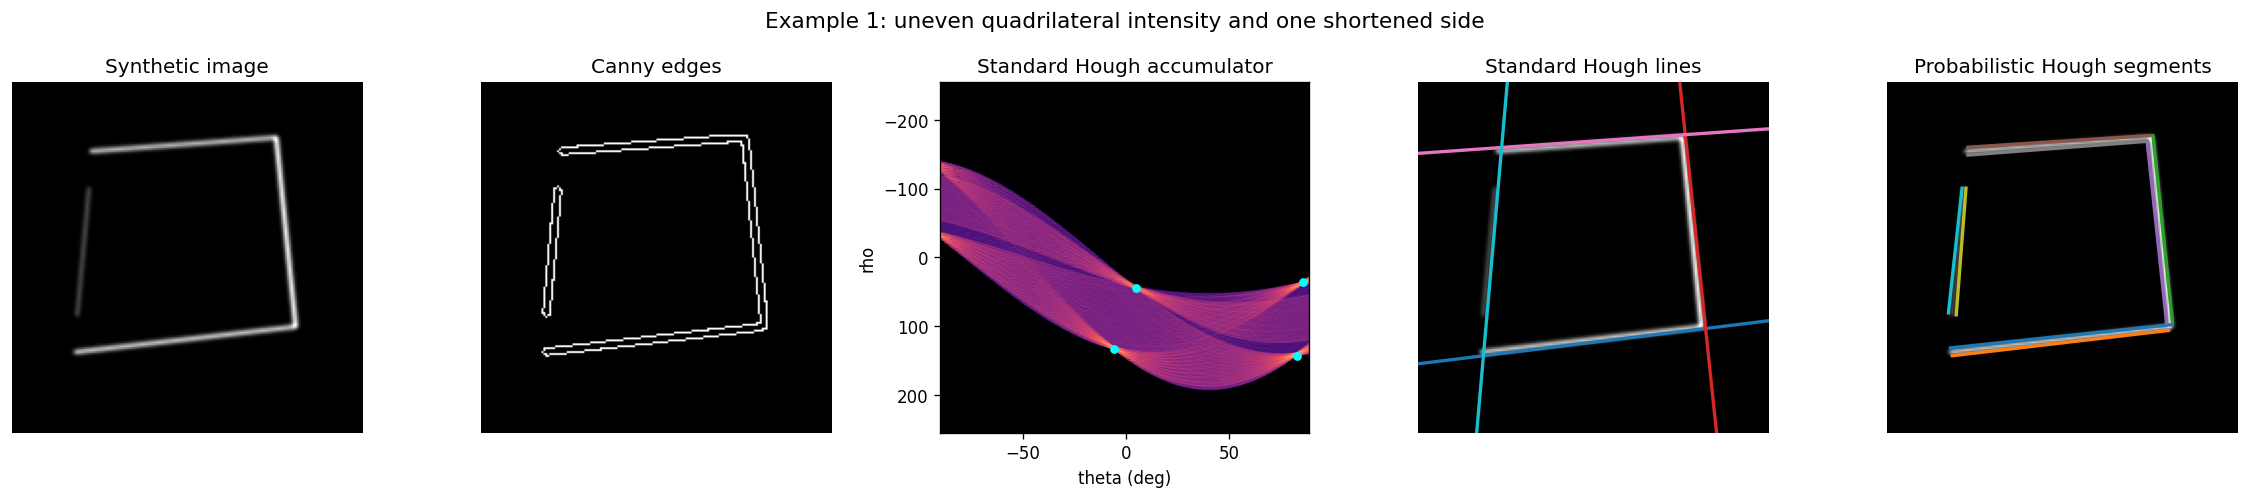

Standard Hough peaks:
  01: votes= 90, theta=  83.0 deg, rho=  143.0
  02: votes= 88, theta=  -6.0 deg, rho=  133.0
  03: votes= 72, theta=  86.0 deg, rho=   36.0
  04: votes= 57, theta=   5.0 deg, rho=   45.0

Probabilistic Hough lines (same geometric format when possible):
  01: length= 114.6, theta=  84.0 deg, rho=  138.6, p0=( 32, 136), p1=(146, 124)
  02: length= 111.8, theta=  83.3 deg, rho=  142.9, p0=( 33, 140), p1=(144, 127)
  03: length=  96.5, theta=  -5.9 deg, rho=  132.5, p0=(146, 123), p1=(136,  27)
  04: length=  93.5, theta=  -6.1 deg, rho=  129.0, p0=(143, 123), p1=(133,  30)
  05: length=  93.2, theta=  86.3 deg, rho=   35.6, p0=( 41,  33), p1=(134,  27)
  06: length=  91.3, theta=  85.6 deg, rho=   40.0, p0=( 41,  37), p1=(132,  30)
  07: length=  65.2, theta=   4.4 deg, rho=   44.0, p0=( 35, 119), p1=( 40,  54)
  08: length=  64.4, theta=   6.2 deg, rho=   43.6, p0=( 31, 118), p1=( 38,  54)



In [2]:
img1 = np.zeros((H, W), dtype=float)

A = (35, 40)
B = (28, 135)
C = (125, 145)
D = (138, 32)

draw_segment(img1, A, B, value=0.75)
draw_segment(img1, B, C, value=1.00)
draw_segment(img1, C, D, value=0.80)

# The left edge is deliberately weaker and shorter.
left0, left1 = partial_segment(D, A, 0.18, 0.82)
draw_segment(img1, left0, left1, value=0.28)

img1 = gaussian(img1, sigma=1.1, preserve_range=True)
edges1, acc1, thetas1, rhos1, peaks1 = detect_standard_lines(
    img1,
    canny_sigma=1.2,
    low_threshold=0.03,
    high_threshold=0.10,
    num_peaks=8,
)
_, prob_info1 = detect_probabilistic_lines(
    edges1,
    threshold=50,
    line_length=35,
    line_gap=8,
    seed=None,
)

plot_comparison(
    'Example 1: uneven quadrilateral intensity and one shortened side',
    img1,
    edges1,
    acc1,
    thetas1,
    rhos1,
    peaks1,
    prob_info1,
    max_show=8,
)

print_standard_peaks(*peaks1)
print_probabilistic_lines(prob_info1, max_show=8)


## Example 2: many internal lines compete with the boundary

Now the outer quadrilateral is present, but the image also contains many strong internal segments.

This is a good case for seeing the difference between the two methods:

- standard Hough highlights dominant **global line families**
- probabilistic Hough returns the **actual strongest segments** it finds


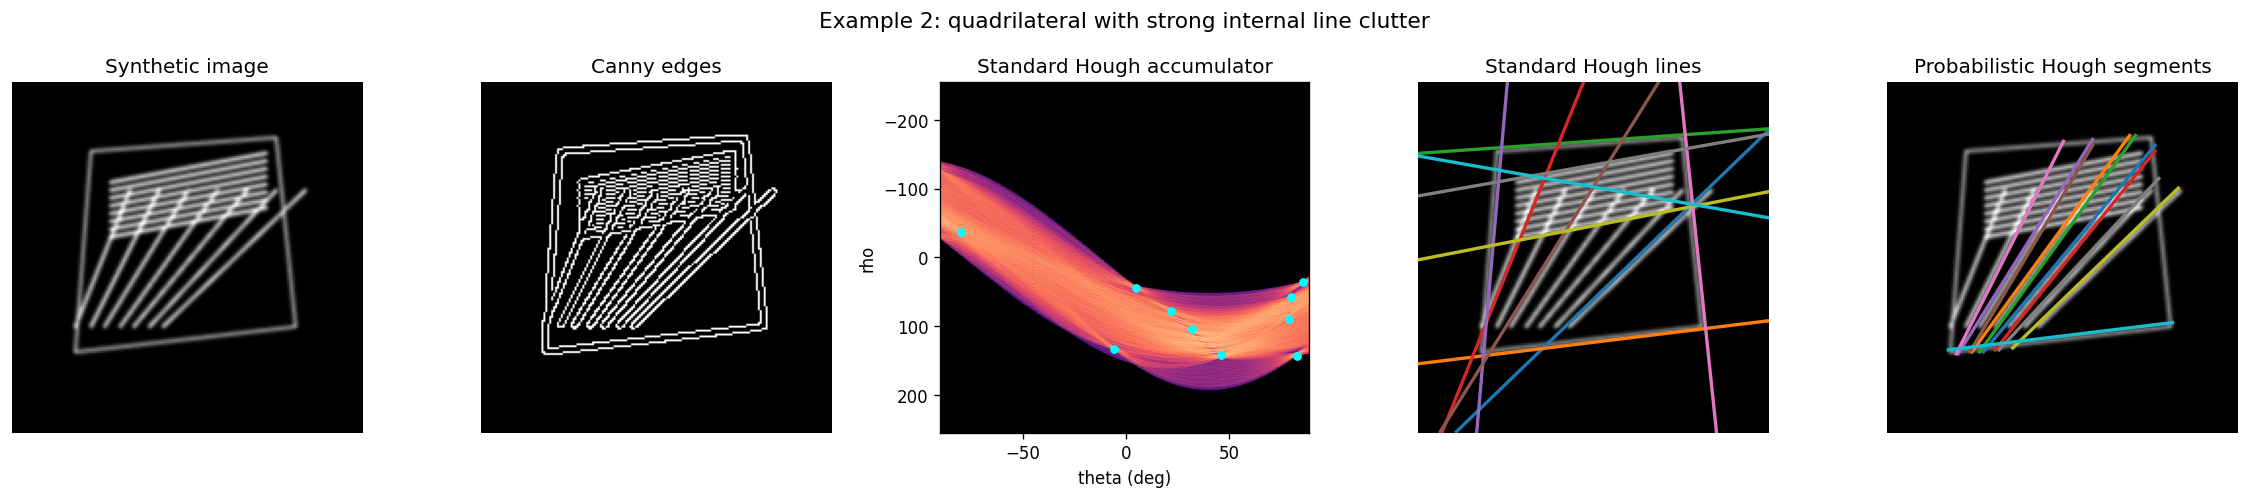

Standard Hough peaks:
  01: votes=103, theta=  46.0 deg, rho=  142.0
  02: votes= 90, theta=  83.0 deg, rho=  143.0
  03: votes= 88, theta=  86.0 deg, rho=   36.0
  04: votes= 78, theta=  22.0 deg, rho=   78.0
  05: votes= 76, theta=   5.0 deg, rho=   45.0
  06: votes= 75, theta=  32.0 deg, rho=  104.0
  07: votes= 74, theta=  -6.0 deg, rho=  133.0
  08: votes= 69, theta=  80.0 deg, rho=   57.0
  09: votes= 62, theta=  79.0 deg, rho=   89.0
  10: votes= 58, theta= -80.0 deg, rho=  -37.0

Probabilistic Hough lines (same geometric format when possible):
  01: length= 137.8, theta=  39.7 deg, rho=  125.8, p0=( 49, 138), p1=(137,  32)
  02: length= 137.4, theta=  36.1 deg, rho=  116.1, p0=( 43, 138), p1=(124,  27)
  03: length= 136.8, theta=  35.8 deg, rho=  118.8, p0=( 47, 138), p1=(127,  27)
  04: length= 130.9, theta=  38.8 deg, rho=  128.7, p0=( 55, 137), p1=(137,  35)
  05: length= 129.8, theta=  32.1 deg, rho=  104.4, p0=( 36, 139), p1=(105,  29)
  06: length= 123.3, theta=  30.7 deg

In [3]:
img2 = np.zeros((H, W), dtype=float)

for p0, p1, value in [(A, B, 0.65), (B, C, 0.65), (C, D, 0.65), (D, A, 0.65)]:
    draw_segment(img2, p0, p1, value=value)

for offset in range(20, 110, 12):
    draw_segment(img2, (45 + offset // 3, 50), (30 + offset // 3, 130), value=1.0)

for offset in range(25, 120, 15):
    draw_segment(img2, (55, 35 + offset), (125, 20 + offset // 2), value=0.9)

img2 = gaussian(img2, sigma=1.0, preserve_range=True)
edges2, acc2, thetas2, rhos2, peaks2 = detect_standard_lines(
    img2,
    canny_sigma=1.0,
    low_threshold=0.04,
    high_threshold=0.11,
    num_peaks=10,
)
_, prob_info2 = detect_probabilistic_lines(
    edges2,
    threshold=50,
    line_length=40,
    line_gap=20,
    seed=None,
)

plot_comparison(
    'Example 2: quadrilateral with strong internal line clutter',
    img2,
    edges2,
    acc2,
    thetas2,
    rhos2,
    peaks2,
    prob_info2,
    max_show=10)

print_standard_peaks(*peaks2)
print_probabilistic_lines(prob_info2, max_show=10)


## What the comparison shows

### Standard Hough

- works in global parameter space
- tends to reveal dominant orientations and offsets
- is very good for saying "there is a line with this geometry"

### Probabilistic Hough

- returns actual finite segments
- is often easier to interpret visually
- can be more sensitive to which local segments are longest and best connected

### In the cluttered example

The probabilistic transform often highlights the strongest clutter segments directly, while the standard transform may still expose line families that correspond to the outer boundary.

That is why the two outputs are related, but not identical.
